# 03 — EDA avancée (Température des cours d’eau)

## Objectifs
1) Caractériser les composantes du signal : saisonnalité annuelle, cycle jour/nuit, différences inter-stations.  
2) Étudier les relations avec les exogènes (température air, pluie, débit) via corrélations et lags.  
3) Isoler les dynamiques locales via décomposition (STL) et étudier l'autocorrélation (ACF/PACF) des résidus.

## Plan 
1. Préparation du split & Chargement 
2. Vue globale & comparaison stations  
3. Saisonnalité annuelle (moyennes mensuelles)  
4. Cycle jour/nuit (profil horaire)  
5. Corrélations croisées & lags exogènes (Température Air, Débit)  
6. Tests statistiques (ADF/KPSS) & Décomposition STL
7. ACF / PACF sur les résidus (Mémoire courte et Inertie)
8. Synthèse (insights & implications pour modèles/ICA)

## 1. Chargement + préparation calendrier  

In [1]:
import numpy as np
import pandas as pd
import sys
import warnings

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning
from pathlib import Path

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (10, 4)

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "base1_clean.parquet"

# Figures (Notebook 03)
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "03_eda_advanced"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Artifacts Notebook 03 (tables + summary)
ART_03 = PROJECT_ROOT / "artifacts" / "03_eda"
ART_03_TBL = ART_03 / "tables"
ART_03_SUM = ART_03 / "summary"

for d in [ART_03, ART_03_TBL, ART_03_SUM]:
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df = df.sort_values(["id_sonde", "ts"]).reset_index(drop=True)

# cree Colonnes calendrier utiles pour l’EDA
df["year"] = df["ts"].dt.year
df["month"] = df["ts"].dt.month
df["dayofyear"] = df["ts"].dt.dayofyear
df["hour"] = df["ts"].dt.hour

# saison "météo"
def month_to_season_fr(m):
    if m in (12, 1, 2): return "hiver"
    if m in (3, 4, 5): return "printemps"
    if m in (6, 7, 8): return "été"
    return "automne"

df["saison"] = df["month"].map(month_to_season_fr).astype("category")

# Résumé dataset
print("Shape:", df.shape)
print("Stations:", df["id_sonde"].nunique(), sorted(df["id_sonde"].unique()))
print("Min ts:", df["ts"].min(), "| Max ts:", df["ts"].max())
print("Missing target (%):", df["temp_water_c"].isna().mean() * 100)


exo_cols = [
    "temp_air_eobs_c", "rainf_eobs",
    "discharge_q", "discharge_q_qjm", "discharge_q_mmj",
    "rain_rr_ref_eobs", "rain_rr_mean_eobs", "temp_tg_ref_eobs"]
exo_cols = [c for c in exo_cols if c in df.columns]

missing_exo = (df[exo_cols].isna().mean() * 100).sort_values(ascending=False).to_frame("pct_missing")
missing_exo["n_missing"] = df[exo_cols].isna().sum()
display(missing_exo)

display(df.head(3))
print("FIG_DIR:", FIG_DIR.resolve())

Shape: (164206, 28)
Stations: 7 [817, 818, 819, 825, 827, 828, 830]
Min ts: 2013-05-29 14:00:00 | Max ts: 2018-10-05 08:00:00
Missing target (%): 0.0


,pct_missing,n_missing
discharge_q,0.576106,946
discharge_q_mmj,0.576106,946
temp_tg_ref_eobs,0.459179,754
discharge_q_qjm,0.303278,498
temp_air_eobs_c,0.000000,0
rainf_eobs,0.000000,0
rain_rr_ref_eobs,0.000000,0
rain_rr_mean_eobs,0.000000,0


,row_id,id_sonde,ts,date,ts_raw,date_raw,temp_water_c,temp_air_eobs_c,rainf_eobs,discharge_q,discharge_q_qjm,discharge_q_mmj,rain_rr_ref_eobs,rain_rr_mean_eobs,temp_tg_ref_eobs,discharge_q__was_missing,discharge_q_qjm__was_missing,discharge_q_mmj__was_missing,temp_tg_ref_eobs__was_missing,rain_rr_ref_eobs__was_missing,rain_rr_mean_eobs__was_missing,dtemp_2h,is_spike_temp_water,year,month,dayofyear,hour,saison
0,46917,817,2013-05-29 14:00:00,2013-05-29,2013-05-29 14:00:00,2013-05-29,12.703,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75,0,0,0,0,0,0,NaN,0,2013,5,149,14,printemps
1,46918,817,2013-05-29 16:00:00,2013-05-29,2013-05-29 16:00:00,2013-05-29,12.896,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75,0,0,0,0,0,0,0.193,0,2013,5,149,16,printemps
2,46919,817,2013-05-29 18:00:00,2013-05-29,2013-05-29 18:00:00,2013-05-29,12.968,9.75,2.8,18.1,18.1,0.717358,2.8,3.360976,9.75,0,0,0,0,0,0,0.072,0,2013,5,149,18,printemps


FIG_DIR: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced


In [2]:
# Split
VAL_START  = pd.Timestamp("2018-01-01")
TEST_START = pd.Timestamp("2018-07-01")

assert pd.api.types.is_datetime64_any_dtype(df["ts"]), "ts doit être datetime64"

df = df.copy()
df["split"] = np.select(
    [df["ts"] < VAL_START, df["ts"] < TEST_START],
    ["train", "val"],
    default="test")

df_train = df[df["split"] == "train"].copy()

# Affiche les dates pour vérifier
print("Période d'EDA (Train) :", df_train["ts"].min(), "à", df_train["ts"].max())

Période d'EDA (Train) : 2013-05-29 14:00:00 à 2017-12-31 22:00:00


## 2. Vue globale & comparaison inter-stations

Objectif : comparer rapidement les stations sur le dataset d’entraînement (niveau moyen, dispersion, dynamique globale) à l’aide de figures synthétiques :
- séries temporelles par station,
- boxplot par station.

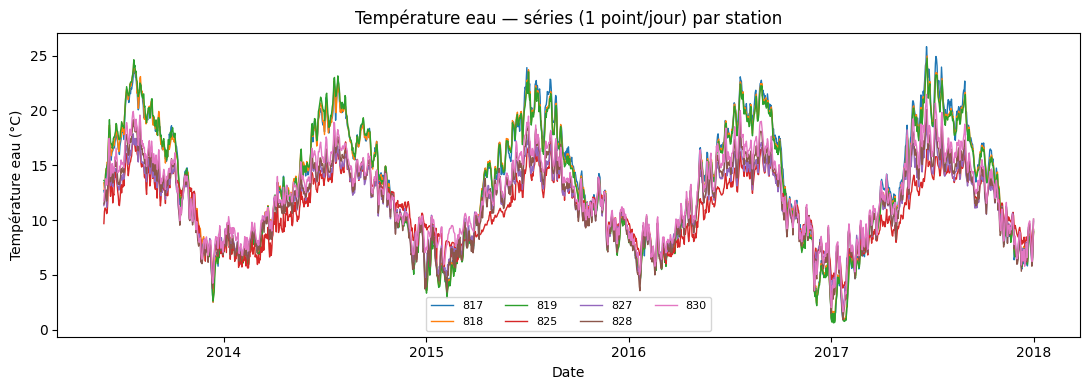

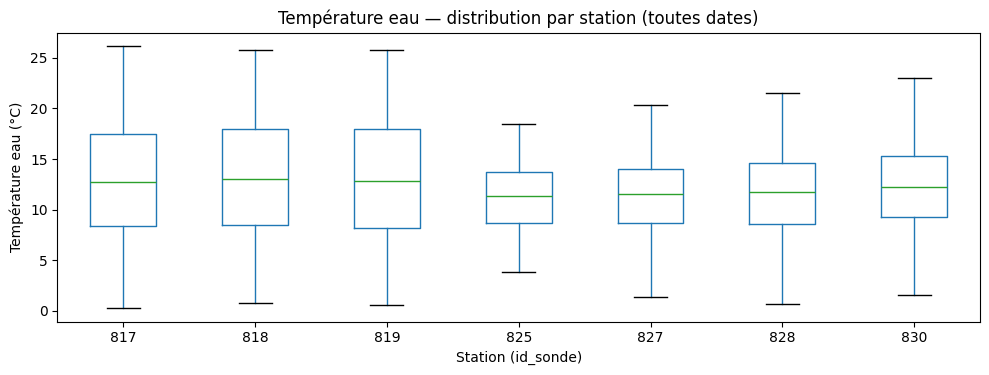

In [3]:

STEP = 12  # 12 pas de 2h = 1 jour (affiche 1 point/jour)
stations = sorted(df_train["id_sonde"].unique())

# --- FIG1: séries temporelles (toutes stations) ---
plt.figure(figsize=(11, 4))
for sid in stations:
    g = df_train[df_train["id_sonde"] == sid].sort_values("ts")
    plt.plot(g["ts"].iloc[::STEP], g["temp_water_c"].iloc[::STEP], label=str(sid), linewidth=1)

plt.title("Température eau — séries (1 point/jour) par station")
plt.xlabel("Date")
plt.ylabel("Température eau (°C)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_overview_series_daily_by_station.png", dpi=200, bbox_inches="tight")
plt.show()

# --- FIG2: boxplot par station (niveau/dispersion) ---
fig, ax = plt.subplots(figsize=(10, 4))
df_train.boxplot(column="temp_water_c", by="id_sonde", grid=False, ax=ax)

ax.set_title("Température eau — distribution par station (toutes dates)")
fig.suptitle("") 
ax.set_xlabel("Station (id_sonde)")
ax.set_ylabel("Température eau (°C)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_overview_boxplot_by_station.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
station_stats = (
    df_train.groupby("id_sonde")["temp_water_c"]
    .agg(n="count", mean="mean", std="std", min="min", median="median", max="max")
    .round(3)
    .reset_index()
    .sort_values("id_sonde"))

display(station_stats)

station_stats.to_csv(ART_03_TBL / "eda_station_temp_summary_train.csv", index=False)

,id_sonde,n,mean,std,min,median,max
0,817,20129,12.972,5.313,0.218,12.727,26.182
1,818,20129,13.245,5.428,0.770,12.992,25.817
2,819,20129,13.099,5.514,0.570,12.816,25.812
3,825,20129,11.219,2.937,3.775,11.370,18.438
4,827,20129,11.338,3.218,1.398,11.540,20.341
5,828,20129,11.605,3.660,0.632,11.783,21.557
6,830,20129,12.221,3.628,1.507,12.219,22.968


### Résultats — comparaison inter-stations

Les séries journalières montrent une dynamique globale synchronisée entre stations, ce qui suggère un forçage commun (météo / saison).

Les différences portent surtout sur le niveau et la variabilité :
- **817/818/819** : stations les plus chaudes et les plus variables ;
- **825** : station plus froide et plus stable (amplitude plus faible) ;
- **827/828/830** : profils intermédiaires.

Ces résultats justifient l’introduction d’un **effet station** dans la modélisation.

## 3. Saisonnalité annuelle (moyennes mensuelles)

Objectif : mettre en évidence le cycle saisonnier annuel de la température de l’eau sur le dataset d’entraînement, en comparant les moyennes mensuelles par station.

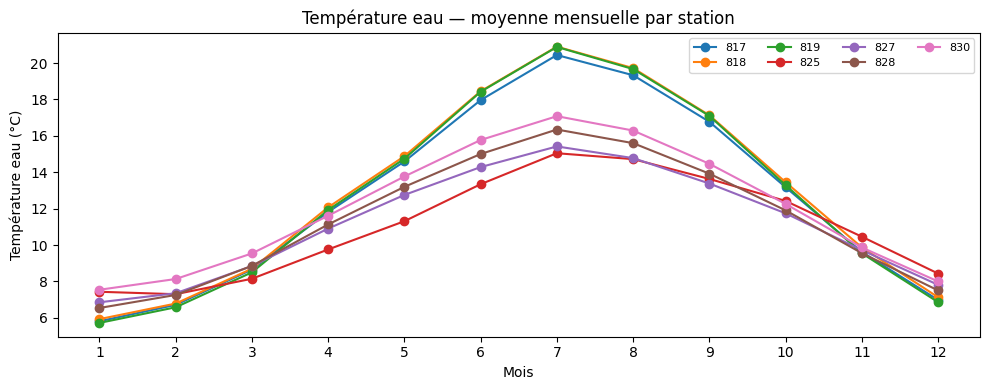

In [5]:
# --- FIG3: cycle saisonnier annuel : moyenne mensuelle par station ---
monthly = (
    df_train.groupby(["id_sonde", "month"])["temp_water_c"]
    .mean()
    .reset_index()
    .sort_values(["id_sonde", "month"]))

plt.figure(figsize=(10, 4))
for sid in stations:
    mm = monthly[monthly["id_sonde"] == sid]
    plt.plot(mm["month"], mm["temp_water_c"], marker="o", label=str(sid))

plt.title("Température eau — moyenne mensuelle par station")
plt.xlabel("Mois")
plt.ylabel("Température eau (°C)")
plt.xticks(range(1, 13))
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_overview_monthly_mean_by_station.png", dpi=200, bbox_inches="tight")
plt.show()

### Résultats — saisonnalité annuelle

Les moyennes mensuelles montrent une **saisonnalité annuelle forte et synchronisée** : hausse au printemps, pic en été (juillet–août), baisse en automne/hiver.

Les écarts entre stations restent visibles sur toute l’année :
- **817/818/819** ont les niveaux les plus élevés,
- **825** reste la plus froide,
- **827/828/830** sont intermédiaires.

Les écarts sont plus marqués en été, ce qui suggère un possible **effet station × saison**.

### Synthèse (Sections 2–3)

Le signal de température combine :
- une composante commune forte (saisonnalité),
- et des effets locaux (niveau/amplitude selon la station, notamment 825).

## 4. Cycle jour/nuit (profil horaire)

Objectif : caractériser la composante intra-journalière (jour/nuit) de la température d’eau, et visualiser son interaction avec la saison.

Figures :
- Profil horaire moyen (toutes dates) : `hour => mean(Teau)` par station.
- Heatmap `mois × heure` : moyenne de `Teau` pour visualiser saisonnalité + jour/nuit en une figure.

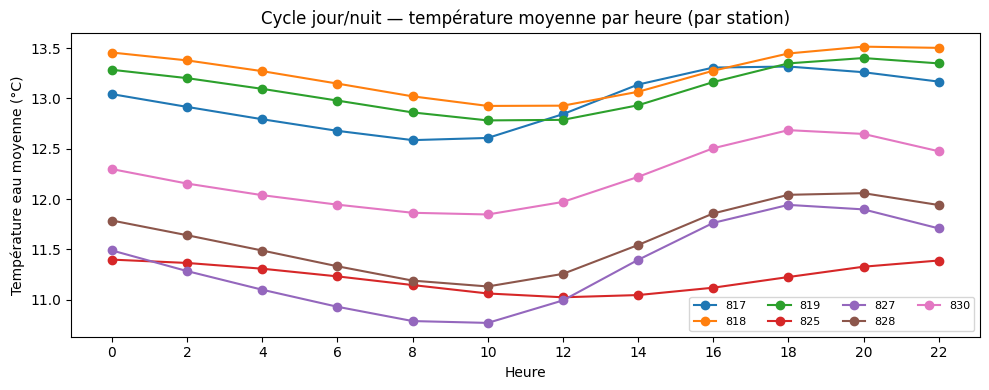

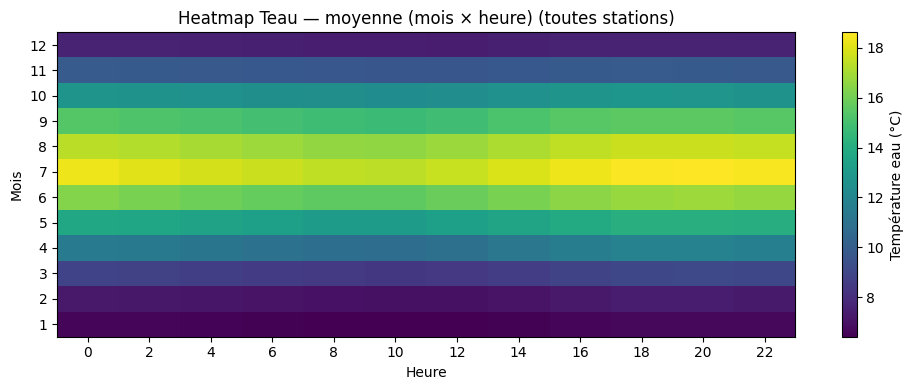

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig04_diel_hourly_mean_by_station.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig05_heatmap_month_by_hour_all_stations.png


In [6]:
stations = sorted(df_train["id_sonde"].unique())

# --- FIG4: Profil horaire moyen par station ---
hourly = (df_train.groupby(["id_sonde", "hour"])["temp_water_c"]
            .mean()
            .reset_index()
            .sort_values(["id_sonde", "hour"]))

plt.figure()
for sid in stations:
    g = hourly[hourly["id_sonde"] == sid]
    plt.plot(g["hour"], g["temp_water_c"], marker="o", label=str(sid))
plt.title("Cycle jour/nuit — température moyenne par heure (par station)")
plt.xlabel("Heure")
plt.ylabel("Température eau moyenne (°C)")
plt.xticks(range(0, 24, 2))
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_diel_hourly_mean_by_station.png", dpi=200, bbox_inches="tight")
plt.show()

# --- FIG5: Heatmap mois × heure (toutes stations) ---
pivot = (df_train.groupby(["month", "hour"])["temp_water_c"]
           .mean()
           .unstack("hour")
           .sort_index())

plt.figure(figsize=(10, 4))
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.title("Heatmap Teau — moyenne (mois × heure) (toutes stations)")
plt.xlabel("Heure")
plt.ylabel("Mois")
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.colorbar(label="Température eau (°C)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_heatmap_month_by_hour_all_stations.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "fig04_diel_hourly_mean_by_station.png")
print("Saved:", FIG_DIR / "fig05_heatmap_month_by_hour_all_stations.png")

### Résultats — cycle jour/nuit 

- Le profil horaire moyen met en évidence un **cycle jour/nuit** : la température d’eau est généralement plus basse en matinée (env 8–10h) et augmente progressivement pour atteindre un maximum en fin d’après-midi / soirée (env 18–22h). L’amplitude reste modérée (env quelques dixièmes à env1°C selon les stations), ce qui est cohérent avec l’inertie thermique du milieu aquatique.

- La heatmap (mois × heure) confirme que la **saisonnalité annuelle** est la composante dominante (hiver froid, été chaud), et montre que la composante jour/nuit est **plus marquée en été** qu’en hiver. Cela motive l’utilisation de variables calendaires (heure, mois) et/ou de composantes saisonnières multiples (annuelle + intra-journalière) dans les analyses et modèles ultérieurs.

## 5. Corrélations croisées & lags exogènes (air, débit, pluie)

Objectif : (i) mesurer la mémoire/saisonnalité de `temp_water_c` via ACF/PACF, (ii) estimer les retards typiques entre la température de l’eau et les variables exogènes (air, débit, pluie) via des corrélations en fonction du lag.

Remarque : on calcule ici des corrélations de type `corr(Teau(t), X(t-lag))` avec `lag ≥ 0` (passé → présent), cohérent avec le forecasting.

In [7]:
from src.eda_lagcorr import LagCorrConfig, compute_bestlags, export_bestlags
from pathlib import Path

cfg = LagCorrConfig(split_col="split", split_value="train",
                    exo_cols=("temp_air_eobs_c","discharge_q","rainf_eobs"),
                    max_lag_days=7, step_hours=2, min_n=50)

bestlags, pivot, _ = compute_bestlags(df, config=cfg, return_curves=False)
display(pivot)

export_bestlags(bestlags, pivot, out_dir=ART_03_TBL)

best_lag_hours                              best_corr                           
exo         discharge_q rainf_eobs temp_air_eobs_c discharge_q rainf_eobs temp_air_eobs_c
id_sonde                                                                                 
817                10.0       68.0            24.0   -0.480394  -0.087979        0.934908
818                14.0       88.0            26.0   -0.505452  -0.085217        0.930848
819                12.0      110.0            28.0   -0.503512  -0.083651        0.929974
825                18.0       78.0            22.0   -0.454874  -0.064602        0.919011
827                16.0       62.0            14.0   -0.481845  -0.079909        0.956944
828                20.0       66.0            16.0   -0.465127  -0.081630        0.961879
830                16.0       66.0            20.0   -0.457450  -0.080824        0.936441

### Résultats — corrélations avec retards (lags)

Nous avons estimé des corrélations de type **Pearson** `corr(Teau(t), X(t-lag))` avec `lag >= 0` (passé => présent), **sur la période d’entraînement définie a priori** (`ts < 2018-01-01`), afin d’identifier des retards plausibles compatibles avec un usage en prévision.

- **Température de l’air (`temp_air_eobs_c`)** : la corrélation est maximale pour un retard proche d’une journée (**~ 14–28h**) sur plusieurs stations (**corr ~ 0.92–0.96**). Ceci suggère que la température de l’air est un déterminant majeur de la température de l’eau, avec un délai cohérent avec l’**inertie thermique** du milieu.

- **Débit (`discharge_q`)** : corrélation négative modérée (**corr ~ -0.45 à -0.51**), avec un lag variable selon les stations (**~ 10–20h**). Ce résultat est compatible avec un effet de refroidissement/mélange et/ou une inertie hydrologique, mais peut aussi refléter une **saisonnalité partagée** (hiver : débit ↑ et eau ↓). Cela sera vérifié via des modèles contrôlant la saisonnalité (ex. SARIMAX, régressions régularisées avec features calendaires).

- **Pluie (`rainf_eobs`)** : corrélations faibles (**|corr| ~ 0.06–0.09**) avec des lags plus longs (**~ 62–110h**), suggérant un rôle direct limité à cette échelle. Un effet indirect via le débit ou des transformations (ex. **cumuls 24/48/72h**, variables retardées) sera exploré.

> Remarque : ces corrélations sont descriptives (corrélation ≠ causalité) et capturent principalement des relations linéaires.

## 6. Diagnostics statistiques et structure du signal (TRAIN)

Objectif : compléter l’EDA visuelle par des diagnostics sur la période d’entraînement :
- stationnarité (ADF / KPSS),
- similarité inter-stations (corrélations journalières),
- décomposition STL (tendance, saisonnalité, résidu).

### 6.1 Tests de stationnarité (ADF / KPSS)

Objectif : évaluer si la série `temp_water_c` est stationnaire sur TRAIN, puis après dé-saisonnalisation simple (moyenne `mois × heure`).

- **ADF** : H0 = racine unitaire (non-stationnaire)
- **KPSS** : H0 = stationnaire

Remarque : avec une forte saisonnalité, ces tests servent surtout de **diagnostic** pour guider la modélisation 

In [8]:
df_train = df[df["split"] == "train"].copy()

def adf_pvalue(s):
    s = s.dropna()
    if len(s) < 200:
        return np.nan
    return adfuller(s, autolag="AIC")[1]

def kpss_pvalue(s, regression="c"):
    s = s.dropna()
    if len(s) < 200:
        return np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        stat, p, lags, crit = kpss(s, regression=regression, nlags="auto")
    return p

rows = []
for sid, g in df_train.groupby("id_sonde"):
    g = g.sort_values("ts")

    y = g["temp_water_c"]

    seasonal_mean = g.groupby(["month", "hour"])["temp_water_c"].transform("mean")
    y_deseason = y - seasonal_mean

    rows.append({
        "id_sonde": sid,
        "n_obs_train": int(y.notna().sum()),

        "adf_p": adf_pvalue(y),
        "kpss_p_c": kpss_pvalue(y, regression="c"),
        "kpss_p_ct": kpss_pvalue(y, regression="ct"),

        "adf_p_deseason": adf_pvalue(y_deseason),
        "kpss_p_c_deseason": kpss_pvalue(y_deseason, regression="c"),
        "kpss_p_ct_deseason": kpss_pvalue(y_deseason, regression="ct"),})

tests_stationarity = pd.DataFrame(rows).sort_values("id_sonde").reset_index(drop=True)

#(alpha=0.05):
# - ADF rejette H0 non-stationnaire si p<0.05
# - KPSS rejette H0 stationnaire si p<0.05
alpha = 0.05
tests_stationarity["adf_stationary"] = tests_stationarity["adf_p"] < alpha
tests_stationarity["kpss_stationary_c"] = tests_stationarity["kpss_p_c"] >= alpha
tests_stationarity["kpss_stationary_ct"] = tests_stationarity["kpss_p_ct"] >= alpha

tests_stationarity["adf_stationary_deseason"] = tests_stationarity["adf_p_deseason"] < alpha
tests_stationarity["kpss_stationary_c_deseason"] = tests_stationarity["kpss_p_c_deseason"] >= alpha
tests_stationarity["kpss_stationary_ct_deseason"] = tests_stationarity["kpss_p_ct_deseason"] >= alpha

display(tests_stationarity)

,id_sonde,n_obs_train,adf_p,kpss_p_c,kpss_p_ct,adf_p_deseason,kpss_p_c_deseason,kpss_p_ct_deseason,adf_stationary,kpss_stationary_c,kpss_stationary_ct,adf_stationary_deseason,kpss_stationary_c_deseason,kpss_stationary_ct_deseason
0,817,20129,0.095462,0.082751,0.01,1.471605e-17,0.10,0.054170,False,True,False,True,True,True
1,818,20129,0.090192,0.076259,0.01,1.308734e-16,0.10,0.048995,False,True,False,True,True,False
2,819,20129,0.085730,0.064355,0.01,5.676170e-17,0.10,0.048950,False,True,False,True,True,False
3,825,20129,0.020073,0.044862,0.01,4.051228e-16,0.01,0.010000,True,False,False,True,False,False
4,827,20129,0.001718,0.100000,0.01,9.792282e-24,0.10,0.100000,True,True,False,True,True,True
5,828,20129,0.002437,0.097175,0.01,2.358779e-20,0.10,0.100000,True,True,False,True,True,True
6,830,20129,0.008620,0.092599,0.01,3.972096e-19,0.10,0.074036,True,True,False,True,True,True


### Tests de stationnarité (TRAIN) — ADF & KPSS

Nous avons appliqué deux tests complémentaires sur `temp_water_c` (période d’entraînement définie a priori) :
- **ADF** : H0 = présence d’une racine unitaire (non-stationnarité) ; p < 0.05 ⇒ rejet de H0.
- **KPSS** : H0 = stationnarité ; p < 0.05 ⇒ rejet de H0 (non-stationnarité).

Sur la série brute, les résultats varient selon les stations : les stations 817–819 ne rejettent pas systématiquement la non-stationnarité (ADF p ≈ 0.086–0.095), alors que d’autres stations rejettent fortement (ADF p < 0.01). La station 825 présente un comportement particulier (ADF p ≈ 0.02 mais KPSS(c) p ≈ 0.045), suggérant une instabilité plus marquée.

Après une **dé-saisonnalisation simple** (retrait de la moyenne conditionnelle mois×heure calculée sur TRAIN), les p-values ADF deviennent très faibles pour toutes les stations (p ≪ 0.001), indiquant que la structure saisonnière annuelle  ,explique une grande partie de la non-stationnarité apparente. Le test KPSS(c) confirme une stationnarité résiduelle pour la majorité des stations (p ≈ 0.10), tandis que la station 825 reste non-stationnaire (p ≈ 0.01), motivant un diagnostic complémentaire (tendance/rupture) et possiblement un traitement spécifique.

> Remarque : ces tests sont utilisés ici comme **diagnostics** ; ils sont sensibles à la saisonnalité et à l’autocorrélation, et ne constituent pas une preuve de causalité ni une validation de modèle.

### 6.2 Similarité inter-stations (corrélation journalière)

Objectif : mesurer la similarité entre stations à partir des **moyennes journalières** de température de l’eau sur TRAIN.
Cette matrice complète la vue globale en quantifiant les proximités inter-stations.

id_sonde,817,818,819,825,827,828,830
id_sonde,,,,,,,
817,1.000000,0.998048,0.997580,0.945245,0.974405,0.979790,0.981669
818,0.998048,1.000000,0.999211,0.943711,0.971186,0.976591,0.978037
819,0.997580,0.999211,1.000000,0.944375,0.970655,0.976073,0.977911
825,0.945245,0.943711,0.944375,1.000000,0.946148,0.943112,0.941978
827,0.974405,0.971186,0.970655,0.946148,1.000000,0.997838,0.985473
828,0.979790,0.976591,0.976073,0.943112,0.997838,1.000000,0.990733
830,0.981669,0.978037,0.977911,0.941978,0.985473,0.990733,1.000000


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\03_eda\tables\corr_matrix_stations_daily_train.csv


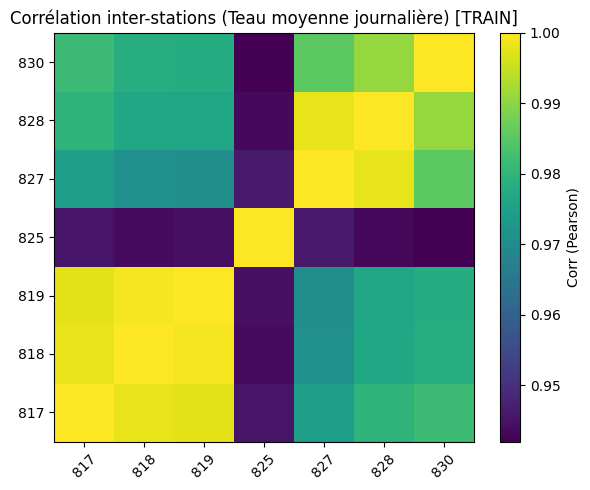

In [9]:
df_train = df[df["split"] == "train"].copy()

daily = (df_train
         .set_index("ts")
         .groupby("id_sonde")["temp_water_c"]
         .resample("1D").mean()
         .reset_index())

pivot = daily.pivot(index="ts", columns="id_sonde", values="temp_water_c")

corr_mat = pivot.corr(min_periods=200)
display(corr_mat)

# export table
out_dir = ART_03_TBL
corr_mat.to_csv(out_dir / "corr_matrix_stations_daily_train.csv")
print("Saved:", out_dir / "corr_matrix_stations_daily_train.csv")

# Heatmap matplotlib
plt.figure(figsize=(6, 5))
plt.imshow(corr_mat.values, aspect="auto", origin="lower")
plt.title("Corrélation inter-stations (Teau moyenne journalière) [TRAIN]")
plt.xticks(ticks=np.arange(len(corr_mat.columns)), labels=corr_mat.columns, rotation=45)
plt.yticks(ticks=np.arange(len(corr_mat.index)), labels=corr_mat.index)
plt.colorbar(label="Corr (Pearson)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_corr_matrix_stations_daily_train.png", dpi=200, bbox_inches="tight")
plt.show()

### Résultats — similarité inter-stations [TRAIN]

La matrice de corrélation (sur les moyennes journalières de `temp_water_c`) met en évidence une forte cohérence inter-stations, avec deux groupes principaux :
- **(817, 818, 819)** : corrélations très élevées (~ 0.998–0.999), indiquant un signal quasiment commun.
- **(827, 828, 830)** : corrélations également élevées (~ 0.985–0.998), suggérant une dynamique similaire au sein de ce groupe.

La station **825** apparaît plus distincte, avec des corrélations plus faibles (~0.942–0.946) vis-à-vis des autres stations, ce qui est cohérent avec les analyses précédentes (niveau plus faible et variabilité réduite). Ces regroupements motivent l’étude de modèles globaux avec effet station, et constituent une base pertinente pour l’analyse en composantes (FastICA).

### 6.3 Décomposition STL (saisonnalité annuelle & résidus)

Objectif : séparer la série en composantes (tendance, saisonnalité annuelle, résidu) afin d’identifier :
- l’importance de la saisonnalité,
- des différences inter-stations (ex. station plus inertielle),
- des événements locaux visibles dans le résidu.

Méthode : on travaille sur la **moyenne journalière** (réduction du bruit 2h) et on applique une STL avec période annuelle (~365 jours) sur TRAIN.

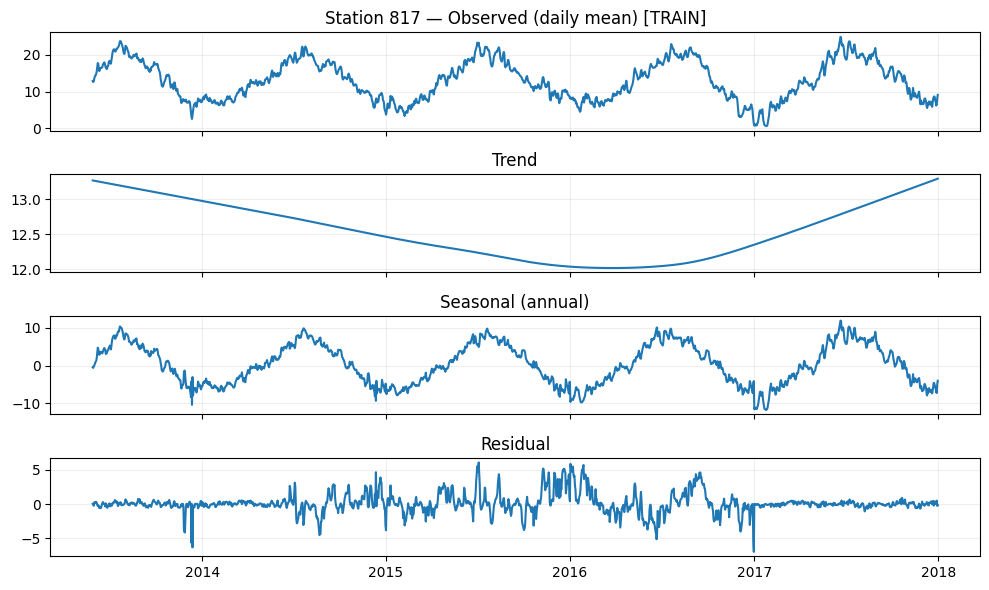

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig10_stl_annual_station817_train.png


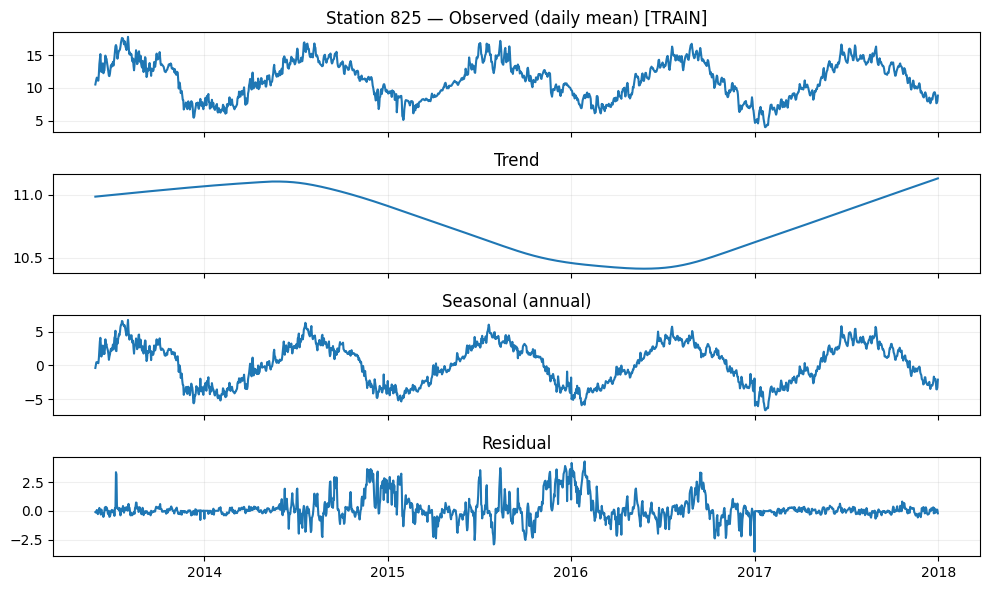

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig10_stl_annual_station825_train.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\03_eda\tables\stl_seasonal_strength_annual_train.csv


,id_sonde,seasonal_strength_annual
0,817,0.922084
1,825,0.874095


In [10]:
stations_to_show = [817, 825]

def stl_decompose_daily(df_in, sid, period_days=365):
    g = (df_in[df_in["id_sonde"] == sid]
         .set_index("ts")["temp_water_c"]
         .resample("1D").mean()
         .dropna())
    # STL annuel sur série journalière
    res = STL(g, period=period_days, robust=True).fit()
    return g, res

def seasonal_strength(res):
    resid = res.resid.dropna()
    seas = res.seasonal.dropna()
    common = resid.index.intersection(seas.index)
    resid = resid.loc[common]
    seas = seas.loc[common]
    denom = np.var(resid + seas)
    return float(1 - np.var(resid) / denom) if denom > 0 else np.nan

strength_rows = []

for sid in stations_to_show:
    daily, res = stl_decompose_daily(df_train, sid, period_days=365)
    s_strength = seasonal_strength(res)
    strength_rows.append({"id_sonde": sid, "seasonal_strength_annual": s_strength})

    # Fig STL (4 panneaux)
    fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(daily.index, daily.values); axes[0].set_title(f"Station {sid} — Observed (daily mean) [TRAIN]")
    axes[1].plot(res.trend.index, res.trend.values); axes[1].set_title("Trend")
    axes[2].plot(res.seasonal.index, res.seasonal.values); axes[2].set_title("Seasonal (annual)")
    axes[3].plot(res.resid.index, res.resid.values); axes[3].set_title("Residual")
    for ax in axes: ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig_path = FIG_DIR / f"fig10_stl_annual_station{sid}_train.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


strength_df = pd.DataFrame(strength_rows)
out_dir = ART_03_TBL
out_dir.mkdir(parents=True, exist_ok=True)
strength_df.to_csv(out_dir / "stl_seasonal_strength_annual_train.csv", index=False)
print("Saved:", out_dir / "stl_seasonal_strength_annual_train.csv")

display(strength_df)

### Résultats — décomposition STL (saisonnalité annuelle & résidus)

La décomposition STL sur la moyenne journalière (TRAIN) confirme une **composante saisonnière annuelle dominante** pour les stations illustratives :

- **Station 817** : `seasonal_strength_annual = 0.922`
- **Station 825** : `seasonal_strength_annual = 0.874`

Ces valeurs élevées (proches de 1) indiquent que la variabilité de `temp_water_c` est largement expliquée par la **saisonnalité annuelle**.

La station **825** reste néanmoins légèrement moins “saisonnière” que 817 (force saisonnière plus faible), ce qui suggère une part relativement plus importante de **dynamique locale / résiduelle** (effets locaux, variabilité non strictement saisonnière).

Sur la figure STL (station 825), la tendance est lente et de faible amplitude, tandis que la composante saisonnière reproduit bien le cycle annuel. Le résidu met en évidence des fluctuations locales plus courtes, qui seront analysées via **ACF/PACF** dans la section suivante.

## 7. ACF / PACF sur les résidus STL (mémoire courte)

Objectif : analyser la dépendance temporelle restante après retrait de la tendance et de la saisonnalité annuelle (STL), via les fonctions d’autocorrélation (ACF) et d’autocorrélation partielle (PACF).

Remarque : comme la STL est appliquée sur la **moyenne journalière**, les lags ACF/PACF sont ici exprimés en **jours**.

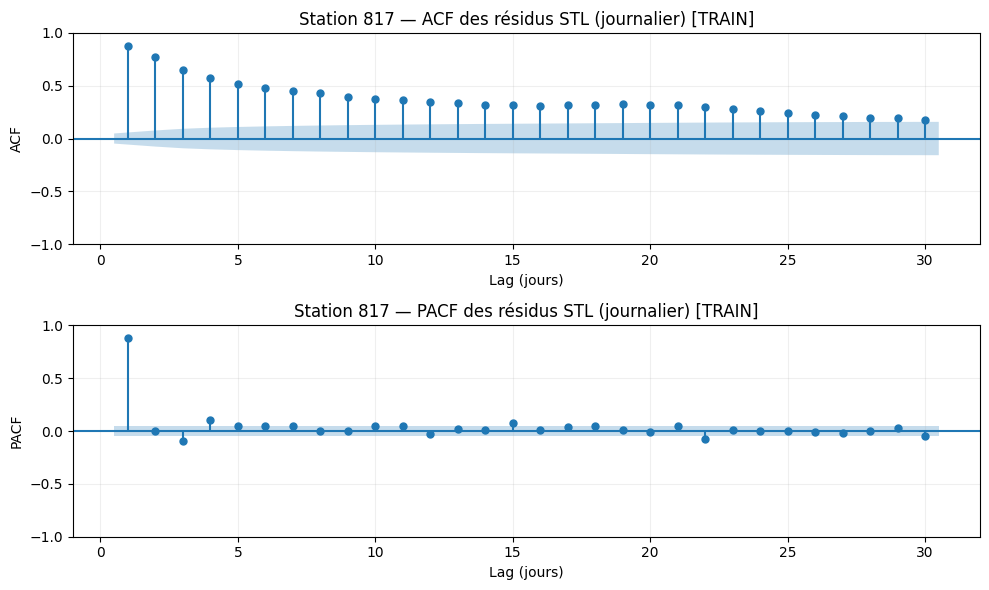

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig11_acf_pacf_stl_resid_station817_train.png


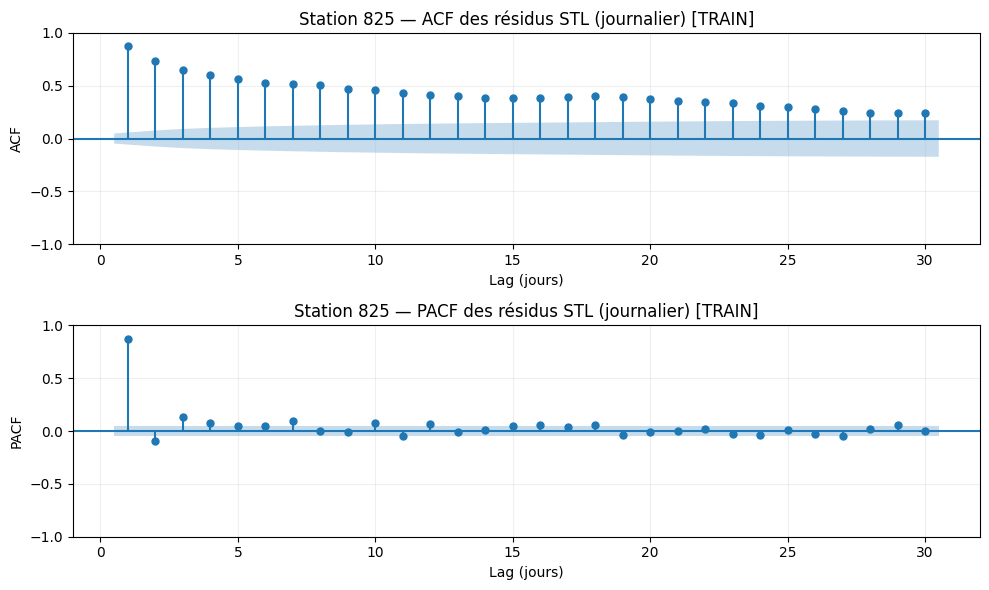

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\03_eda_advanced\fig11_acf_pacf_stl_resid_station825_train.png


In [11]:
# --- ACF / PACF sur résidus STL (série journalière) ---

MAX_LAGS_DAYS = 30  # lags en jours 
for sid in stations_to_show:
    daily, res = stl_decompose_daily(df_train, sid, period_days=365)

    resid = pd.Series(res.resid, index=daily.index).dropna()
    if len(resid) < 50:
        print(f"Station {sid}: trop peu de points pour ACF/PACF")
        continue

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    plot_acf(resid, lags=MAX_LAGS_DAYS, ax=axes[0], zero=False)
    axes[0].set_title(f"Station {sid} — ACF des résidus STL (journalier) [TRAIN]")
    axes[0].set_xlabel("Lag (jours)")
    axes[0].set_ylabel("ACF")
    axes[0].grid(True, alpha=0.2)

    plot_pacf(resid, lags=MAX_LAGS_DAYS, ax=axes[1], method="ywm", zero=False)
    axes[1].set_title(f"Station {sid} — PACF des résidus STL (journalier) [TRAIN]")
    axes[1].set_xlabel("Lag (jours)")
    axes[1].set_ylabel("PACF")
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    fig_path = FIG_DIR / f"fig11_acf_pacf_stl_resid_station{sid}_train.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

### Résultats — ACF/PACF des résidus STL

Pour les stations 817 et 825, l’ACF des résidus STL reste positive et décroît progressivement sur plusieurs jours : les résidus ne sont donc pas un bruit blanc.

La PACF est surtout marquée par un **pic dominant au lag 1 jour**. Au-delà, les coefficients deviennent faibles et oscillent autour de 0 (avec quelques lags légèrement positifs/négatifs, souvent proches de la bande de confiance), ce qui suggère une **mémoire courte** principalement portée par le premier retard.

En résumé, la STL retire la saisonnalité annuelle, mais les résidus conservent une dynamique locale de court terme (inertie sur quelques jours).

## 8. Synthèse — EDA avancée (points clés)

- Les 7 stations présentent une **saisonnalité annuelle forte et synchronisée** (hiver plus froid, été plus chaud), ce qui indique un **forçage commun dominant**.
- Un **cycle jour/nuit** est visible : températures plus basses le matin et plus élevées en fin de journée, avec une amplitude plus marquée en saison chaude.
- Les stations ne sont pas interchangeables : la comparaison inter-stations et la corrélation journalière (TRAIN) mettent en évidence deux groupes proches (**817–818–819** et **827–828–830**), tandis que **825** est plus distincte (plus froide / plus inertielle).
- Les corrélations croisées (TRAIN) montrent que la **température de l’air** est l’exogène la plus informative (corrélation forte, avec retard typique), tandis que le **débit** a un effet négatif modéré ; l’effet direct de la pluie brute reste plus faible à cette échelle.
- Les diagnostics (ADF/KPSS, STL) confirment que la non-stationnarité observée provient en grande partie de la **saisonnalité**.
- La STL (moyenne journalière, TRAIN) montre une **saisonnalité annuelle dominante** (force saisonnière élevée), avec une station **825** légèrement moins dominée par la saisonnalité que **817**, ce qui est cohérent avec des effets locaux plus marqués.
- L’ACF/PACF des résidus STL indique qu’une **mémoire courte** subsiste après retrait de la saisonnalité annuelle (ACF persistante, PACF dominée par le lag 1).

### Implications pour la suite (features / modèles)
- Intégrer des **variables calendaires** (mois, heure, saison) pour capter la structure temporelle.
- Ajouter des **lags exogènes**, en priorité pour la température de l’air (et éventuellement le débit).
- Inclure un **effet station** (et possiblement des interactions station × saison).
- Pour la modélisation, privilégier des approches capables de gérer :
  - la **saisonnalité** (ex. ETS / SARIMAX / régressions avec calendrier),
  - et la **mémoire courte résiduelle** (lags autorégressifs / variables retardées).